# Source: https://scikit-learn.org/stable/auto_examples/decomposition/plot_image_denoising.html

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import sklearn
import matplotlib.pyplot as plt
import pandas as pd

from time import time
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from scipy import stats

seed = 42
rng = np.random.default_rng(seed)

## Import test image from scipy

In [2]:
from scipy.datasets import face

raccoon_face = face(gray=True).astype(np.float64)

# normalize
raccoon_face /= 255.0

# downsample for speed
raccoon_face = raccoon_face[::4, ::4] + raccoon_face[2::4, ::4] + raccoon_face[::4, 2::4] + raccoon_face[2::4, 2::4]
raccoon_face /= 4
height, width = raccoon_face.shape

# Distort the right half of the image
print('Distorting image')
distorted = raccoon_face.copy()
distorted[:, width // 2:] += .075 * rng.standard_normal(size=(height, width // 2))

Distorting image


## Display distorted image

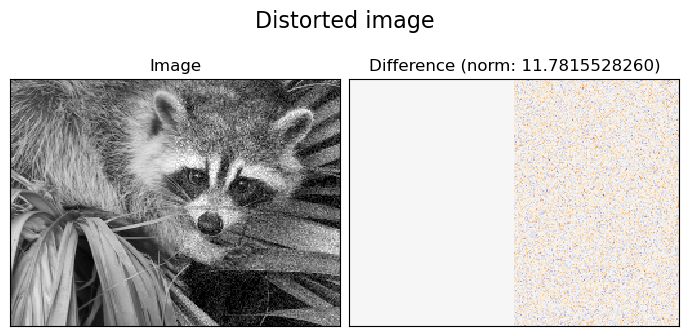

In [3]:
def show_with_diff(image, reference, title):
    plt.figure(figsize=(7, 3.3))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
    
    plt.subplot(1, 2, 2)
    difference = image - reference

    plt.title('Difference (norm: %.10f)' % np.sqrt(np.sum(difference**2)))
    plt.imshow(
        difference, vmin=-0.5, vmax=0.5, cmap=plt.cm.PuOr, interpolation='nearest'
    )
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(title, size=16)
    plt.subplots_adjust(.02, .02, .98, .77, .02, .2)

show_with_diff(distorted, raccoon_face, 'Distorted image')

## Extract reference patches

In [4]:
from time import time
from sklearn.feature_extraction.image import extract_patches_2d

# Extract patches from left half of the image
print('Extracting reference patches')
t0 = time()
patch_size = (9, 9)
data = extract_patches_2d(distorted[:, :width // 2], patch_size)
data = data.reshape(data.shape[0], -1)
data -= np.mean(data, axis=0)
data /= np.std(data, axis=0)
print(f'{data.shape[0]} patches extracted in %.2fs.' % (time() - t0))

Extracting reference patches
22080 patches extracted in 0.02s.


# Import Approx_V1_1

In [5]:
import sys
current_dir = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(current_dir), '../../../')))

In [6]:
from Implementations.AK_SVD.Approx_V1_1 import OMP, kSVD

In [7]:
def plot_log_loss(loss, linestyle='-', alpha = 1):
    plt.semilogy(loss, linestyle=linestyle, alpha = alpha)
    plt.title('Loss vs iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Log Scale)')
    # plt.show()

## Effectively, grid search over a variety of hyperparameters and measure the runtime and performance

In [8]:
# num_iter = 2
Y = data
# T_0 = 1
# batch_size = 256
# dtype = np.float32

In [9]:
from itertools import product

params = {
    'T_0' : [1, 2, 4, 8, 16],
    'k' : [64, 128, 256, 512],
    'num_iter' : [1, 2, 4],
    'rng' : [42],
    'batch_size' : [256],
    'dtype': [np.float32, np.float64]
}

In [10]:
params.items()

dict_items([('T_0', [1, 2, 4, 8, 16]), ('k', [64, 128, 256, 512]), ('num_iter', [1, 2, 4]), ('rng', [42]), ('batch_size', [256]), ('dtype', [<class 'numpy.float32'>, <class 'numpy.float64'>])])

In [11]:
keys, values = zip(*params.items())
combinations = product(*values)

In [12]:
# for combo in combinations:
#     hyperparams = dict(zip(keys, combo))
#     print(hyperparams)

In [13]:
keys

('T_0', 'k', 'num_iter', 'rng', 'batch_size', 'dtype')

In [14]:
rows_list = []
for combo in combinations:
    hyperparams = dict(zip(keys, combo))
    print(hyperparams)
    times = []
    losses = []
    
    T_0 = hyperparams['T_0']
    k = hyperparams['k']
    num_iter = hyperparams['num_iter']
    rng = hyperparams['rng']
    batch_size = hyperparams['batch_size']
    dtype = hyperparams['dtype']
    
    for i in range(5):
        t0 = time()
        D, loss = kSVD(Y = Y, 
                       T_0 = T_0, 
                       k = 300, 
                       num_iter = num_iter, 
                       verbose=0,
                       rng = rng,
                       batch_size = batch_size,
                       dtype = dtype)
        dt = time() - t0
        
        times.append(dt)
        losses.append(loss[-1])

    avg_time = np.average(times)
    avg_loss = np.average(losses)
    print(f'Avg Total Time: {avg_time:.2f} +/- {np.std(times):.2f}')
    print(f'Avg Final Loss: {avg_loss:.2f} +/- {np.std(losses):.2f}')


    if dtype == np.float32:
        dtype = 'FP32'
    elif dtype == np.float64:
        dtype = 'FP64'

    for t, l in zip(times, losses):
        rows_list.append(
            {
                'T_0' : T_0,
                'k' : k,
                'num_iter' : num_iter,
                'rng' : rng,
                'batch_size' : batch_size,
                'dtype' : dtype,
                'time' : t,
                'loss' : l
            }
        )

{'T_0': 1, 'k': 64, 'num_iter': 1, 'rng': 42, 'batch_size': 256, 'dtype': <class 'numpy.float32'>}
Avg Total Time: 0.11 +/- 0.00
Avg Final Loss: 685.58 +/- 0.00
{'T_0': 1, 'k': 64, 'num_iter': 1, 'rng': 42, 'batch_size': 256, 'dtype': <class 'numpy.float64'>}
Avg Total Time: 0.15 +/- 0.01
Avg Final Loss: 700.30 +/- 0.00
{'T_0': 1, 'k': 64, 'num_iter': 2, 'rng': 42, 'batch_size': 256, 'dtype': <class 'numpy.float32'>}
Avg Total Time: 0.17 +/- 0.02
Avg Final Loss: 596.03 +/- 0.00
{'T_0': 1, 'k': 64, 'num_iter': 2, 'rng': 42, 'batch_size': 256, 'dtype': <class 'numpy.float64'>}
Avg Total Time: 0.38 +/- 0.05
Avg Final Loss: 605.05 +/- 0.00
{'T_0': 1, 'k': 64, 'num_iter': 4, 'rng': 42, 'batch_size': 256, 'dtype': <class 'numpy.float32'>}
Avg Total Time: 0.49 +/- 0.05
Avg Final Loss: 564.51 +/- 0.00
{'T_0': 1, 'k': 64, 'num_iter': 4, 'rng': 42, 'batch_size': 256, 'dtype': <class 'numpy.float64'>}
Avg Total Time: 0.81 +/- 0.09
Avg Final Loss: 568.00 +/- 0.00
{'T_0': 1, 'k': 128, 'num_iter': 1

In [15]:
df = pd.DataFrame(rows_list)
df

,T_0,k,num_iter,rng,batch_size,dtype,time,loss
0,1,64,1,42,256,FP32,0.108650,685.581909
1,1,64,1,42,256,FP32,0.101393,685.581909
2,1,64,1,42,256,FP32,0.099084,685.581909
3,1,64,1,42,256,FP32,0.106077,685.581909
4,1,64,1,42,256,FP32,0.109978,685.581909
...,...,...,...,...,...,...,...,...
595,16,512,4,42,256,FP64,6.895760,299.221134
596,16,512,4,42,256,FP64,6.471668,299.221134
597,16,512,4,42,256,FP64,6.923144,299.221134
598,16,512,4,42,256,FP64,7.458609,299.221134


# Fit a Linear Regression model

In [16]:
df_train = pd.get_dummies(df, columns=['dtype'], drop_first=True)
df_train

,T_0,k,num_iter,rng,batch_size,time,loss,dtype_FP64
0,1,64,1,42,256,0.108650,685.581909,False
1,1,64,1,42,256,0.101393,685.581909,False
2,1,64,1,42,256,0.099084,685.581909,False
3,1,64,1,42,256,0.106077,685.581909,False
4,1,64,1,42,256,0.109978,685.581909,False
...,...,...,...,...,...,...,...,...
595,16,512,4,42,256,6.895760,299.221134,True
596,16,512,4,42,256,6.471668,299.221134,True
597,16,512,4,42,256,6.923144,299.221134,True
598,16,512,4,42,256,7.458609,299.221134,True


In [17]:
X = df_train[['T_0', 'k', 'num_iter', 'dtype_FP64']]
X

,T_0,k,num_iter,dtype_FP64
0,1,64,1,False
1,1,64,1,False
2,1,64,1,False
3,1,64,1,False
4,1,64,1,False
...,...,...,...,...
595,16,512,4,True
596,16,512,4,True
597,16,512,4,True
598,16,512,4,True


In [18]:
y = df_train['time']
y

0      0.108650
1      0.101393
2      0.099084
3      0.106077
4      0.109978
         ...   
595    6.895760
596    6.471668
597    6.923144
598    7.458609
599    8.022021
Name: time, Length: 600, dtype: float64

In [19]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
model.coef_

array([ 1.90124874e-01, -6.95113378e-05,  5.18254233e-01,  6.96251350e-01])

In [21]:
model.intercept_

np.float64(-1.4923369569047074)

## Model Diagnostics

In [22]:
# R^2 score
model.score(X, y)

0.7675018645179129

In [23]:
pred = model.predict(X)
residuals = y - pred

Text(0, 0.5, 'residuals')

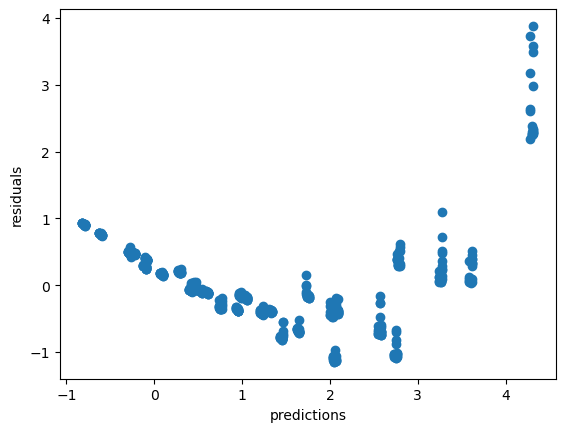

In [24]:
plt.scatter(pred, residuals)
plt.xlabel('predictions')
plt.ylabel('residuals')

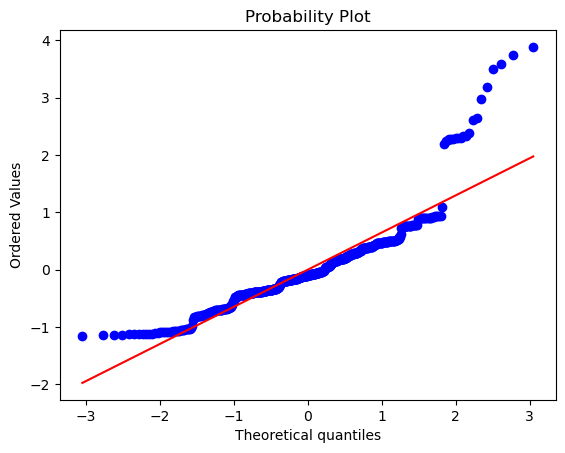

In [25]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

# Since some non-linearity is seen, which is expected, let's try fitting a quadratic model instead

In [26]:
# quad_model = Pipeline([
#     ('poly feats', PolynomialFeatures(degree=2)),
#     ('lin reg', LassoCV(cv=5, random_state=seed))
# ])
quad_model = Pipeline([
    ('poly feats', PolynomialFeatures(degree=2)),
    ('lin reg', LinearRegression())
])
quad_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly feats', ...), ('lin reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [27]:
quad_model.named_steps['lin reg'].coef_

array([ 0.00000000e+00, -1.17724214e-01, -4.51661118e-04, -1.00053973e-01,
       -3.39753309e-01,  3.80689415e-03, -1.75847915e-05,  8.11143997e-02,
        1.14267162e-01,  9.45269363e-07, -1.72336273e-05, -5.77395139e-05,
       -5.13871054e-03,  2.91925305e-01, -3.39753309e-01])

In [28]:
model.intercept_

np.float64(-1.4923369569047074)

In [29]:
quad_model.named_steps['poly feats'].powers_

array([[0, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1],
       [2, 0, 0, 0],
       [1, 1, 0, 0],
       [1, 0, 1, 0],
       [1, 0, 0, 1],
       [0, 2, 0, 0],
       [0, 1, 1, 0],
       [0, 1, 0, 1],
       [0, 0, 2, 0],
       [0, 0, 1, 1],
       [0, 0, 0, 2]])

In [30]:
quad_model.named_steps['poly feats'].feature_names_in_

array(['T_0', 'k', 'num_iter', 'dtype_FP64'], dtype=object)

## Model Diagnostics

In [31]:
# R^2 score
quad_model.score(X, y)

0.9777807302216753

In [32]:
quad_pred = quad_model.predict(X)
quad_residuals = y - quad_pred

Text(0, 0.5, 'residuals')

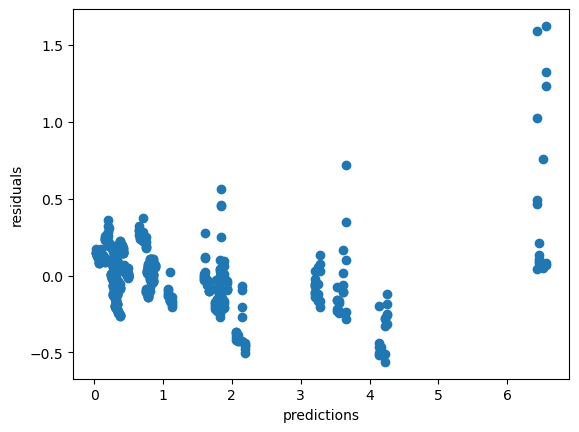

In [33]:
plt.scatter(quad_pred, quad_residuals)
plt.xlabel('predictions')
plt.ylabel('residuals')

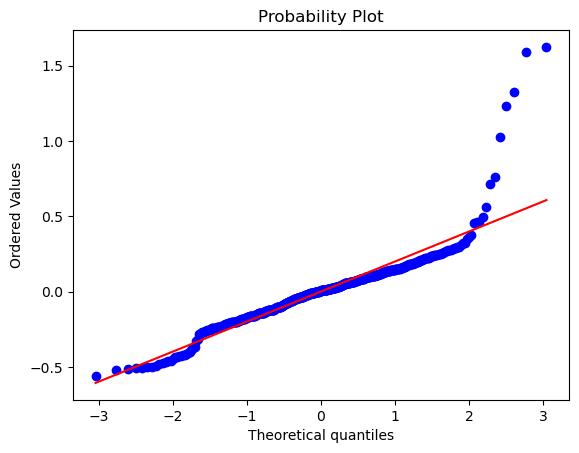

In [34]:
stats.probplot(quad_residuals, dist="norm", plot=plt)
plt.show()

In [35]:
Y.shape

(22080, 81)

In [36]:
df['N'] = Y.shape[0]
df['dim'] = Y.shape[1]
df.insert(0, 'dim', df.pop('dim'))
df.insert(0, 'N', df.pop('N'))
df

,N,dim,T_0,k,num_iter,rng,batch_size,dtype,time,loss
0,22080,81,1,64,1,42,256,FP32,0.108650,685.581909
1,22080,81,1,64,1,42,256,FP32,0.101393,685.581909
2,22080,81,1,64,1,42,256,FP32,0.099084,685.581909
3,22080,81,1,64,1,42,256,FP32,0.106077,685.581909
4,22080,81,1,64,1,42,256,FP32,0.109978,685.581909
...,...,...,...,...,...,...,...,...,...,...
595,22080,81,16,512,4,42,256,FP64,6.895760,299.221134
596,22080,81,16,512,4,42,256,FP64,6.471668,299.221134
597,22080,81,16,512,4,42,256,FP64,6.923144,299.221134
598,22080,81,16,512,4,42,256,FP64,7.458609,299.221134


In [37]:
df.to_csv('9x9.csv', index=False)